# Networks, language, and emotions during a Californian emergency on Bluesky

**Network structure:** Nodes represent users; edges capture likes, reposts, and comments.

**Emotion vs. influence:** Are the most reposted posts also the most emotional?

**Community detection:** Identify user communities through interaction networks (e.g., Louvain algorithm).

**Community language:** Analyze each community's vocabulary using TF-IDF.

**Behavioral differences:** Compare communities by sentiment (how they *feel*) and vocabulary (how they *talk*), and track how it evolves (before, during, and after the disaster).

**Information roles:** Identify authorities, misinformation spreaders, and bridge nodes (e.g., science communicators) and examine how their language differs.

In [ ]:
from atproto import Client
from datetime import datetime

# Initialize client
client = Client()
client.login("your-username", "your-account-password/app-password")

## Getting the data

In [ ]:
import json, time, math
from datetime import datetime, timezone

START = datetime(2025, 1, 1, 0, 0, tzinfo=timezone.utc) # Jan 1st
END   = datetime(2025, 2, 7, 0, 0, tzinfo=timezone.utc) # Feb 7th

POST_FILE  = 'ca_fire_20250101_20250207.jsonl'
INTERACT_FILE= 'interactions_20250101_20250207.jsonl'
LOG_FILE   = 'all_read_dates.txt'

def safe_get(model, path, default=None):
    """walk dot-notation path safely:  safe_get(post, 'record.reply.parent.uri')"""
    for part in path.split('.'):
        model = getattr(model, part, None)
        if model is None:
            return default
    return model or default

def fetch_all_pages(endpoint, params):
    """generic cursor paginator that yields every item in endpoint(params)."""
    cursor = None
    while True:
        try:
            params['cursor'] = cursor
            rsp = endpoint(params)
            yield from getattr(rsp, 'feed', []) or getattr(rsp, 'likes', []) or getattr(rsp, 'reposted_by', [])
            cursor = getattr(rsp, 'cursor', None)
            if not cursor:
                break
            time.sleep(0.2)
        except Exception as e:
            print('paginator error:', e)
            time.sleep(2)

total_posts = 0
cursor      = None
log         = open(LOG_FILE, 'w', encoding='utf8')

'''
while True:
    try:
        rsp = client.app.bsky.feed.search_posts({'q':'#california fire', 'limit':100, 'cursor':cursor})
    except Exception as e:
        print('search error:', e); time.sleep(2); continue
    if not rsp.posts:
        break

    for p in rsp.posts:
        ts = datetime.fromisoformat(p.record.created_at.replace('Z','+00:00'))
        print(ts.date(), ts.time(), file=log)

        if ts >= END:          # too new
            continue
        if ts < START:         # too old → stop
            cursor = None
            break

        # ---------- core post row ----------
        row = {
            "uri"          : p.uri,
            "cid"          : p.cid,
            "created_at"   : p.record.created_at,
            "indexed_at"   : p.indexed_at,
            "author_did"   : p.author.did,
            "author_handle": p.author.handle,
            "text"         : p.record.text,
            "langs"        : getattr(p.record, 'langs', []),
            "reply_to"     : safe_get(p, 'record.reply.parent.uri'),
            "quoted"       : safe_get(p, 'record.embed.record.uri'),
            "like_count"   : p.like_count or 0,
            "repost_count" : p.repost_count or 0
        }
        with open(POST_FILE, 'a', encoding='utf8') as f:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')
        total_posts += 1

        # ---------- interaction rows ----------
        # 1) likes
        for like in fetch_all_pages(client.app.bsky.feed.get_likes,
                                    {'uri': p.uri, 'cid': p.cid, 'limit': 100}):
            with open(INTERACT_FILE, 'a', encoding='utf8') as f:
                f.write(json.dumps({
                    'src_did': like.actor.did,
                    'dst_uri': p.uri,
                    'edge'   : 'like'
                }) + '\n')

        # 2) reposts
        for rep in fetch_all_pages(client.app.bsky.feed.get_reposted_by,
                                   {'uri': p.uri, 'cid': p.cid, 'limit': 100}):
            with open(INTERACT_FILE, 'a', encoding='utf8') as f:
                f.write(json.dumps({
                    'src_did': rep.did,
                    'dst_uri': p.uri,
                    'edge'   : 'repost'
                }) + '\n')

        # 3) replies (direct children only)
        try:
            thread = client.app.bsky.feed.get_post_thread({'uri': p.uri, 'depth': 1})
            for kid in (thread.thread.replies or []):
                with open(INTERACT_FILE, 'a', encoding='utf8') as f:
                    f.write(json.dumps({
                        'src_did': kid.post.author.did,
                        'dst_uri': p.uri,
                        'edge': 'reply'
                    }) + '\n')
        except Exception:
            pass   # post has no thread endpoint / no replies

    cursor = getattr(rsp, 'cursor', None)
    if not cursor:
        break

log.close()
print("finished -> posts:", total_posts,
      "  (interactions appended to", INTERACT_FILE + ")")
'''

### Data exploration

- Basic network statistics
- Comparison of "fire"-related posts tagged within `#California` in January 2025 versus the rest of the year (until October).
- Temporal distribution of posts during January 2025 and early February 2025.

In [ ]:
import pandas as pd

posts  = pd.read_json('ca_fire_20250101_20250207.jsonl', lines=True)
interact = pd.read_json('interactions_20250101_20250207.jsonl', lines=True)

interacted_uris = set(interact['dst_uri'])
all_post_uris   = set(posts['uri'])
lonely_uris     = all_post_uris - interacted_uris

print(f"Posts that received interactions: {len(interacted_uris)}")
print(f"Posts with zero interactions:     {len(lonely_uris)}")

users = set(posts['author_did']) | set(interact['src_did'])
print(f"Distinct users: {len(users)}")

counts = interact['edge'].value_counts()
print("Interactions by type:")
for t, n in counts.items():
    print(f"{t:8s}: {n:,}")

Posts that received interactions: 791
Posts with zero interactions:     551
Distinct users: 6675
Interactions by type:
like    : 6,938
repost  : 1,349
reply   : 522


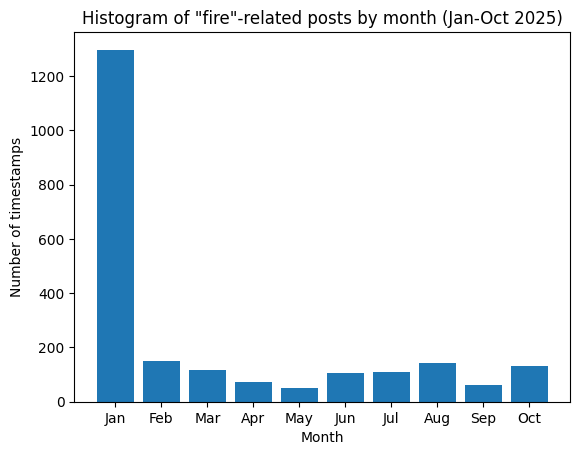

In [8]:
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt

# Read the file
with open('all_read_dates.txt', 'r') as f:
    lines = f.readlines()

# Parse months from lines (ignore year != 2025)
months = []
for line in lines:
    line = line.strip()
    if not line:
        continue
    dt = datetime.fromisoformat(line)
    if dt.year == 2025:  # ignore other years
        months.append(dt.month)

# Count occurrences per month
month_counts = Counter(months)

# Prepare data for plotting (ignore November and December)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct"]  # up to October only

counts = [month_counts.get(i, 0) for i in range(1, 11)]  # months 1–10 only

# Plot histogram
plt.bar(month_names, counts)
plt.xlabel('Month')
plt.ylabel('Number of timestamps')
plt.title('Histogram of "fire"-related posts by month (Jan-Oct 2025)')
plt.show()

All records are within the date interval.


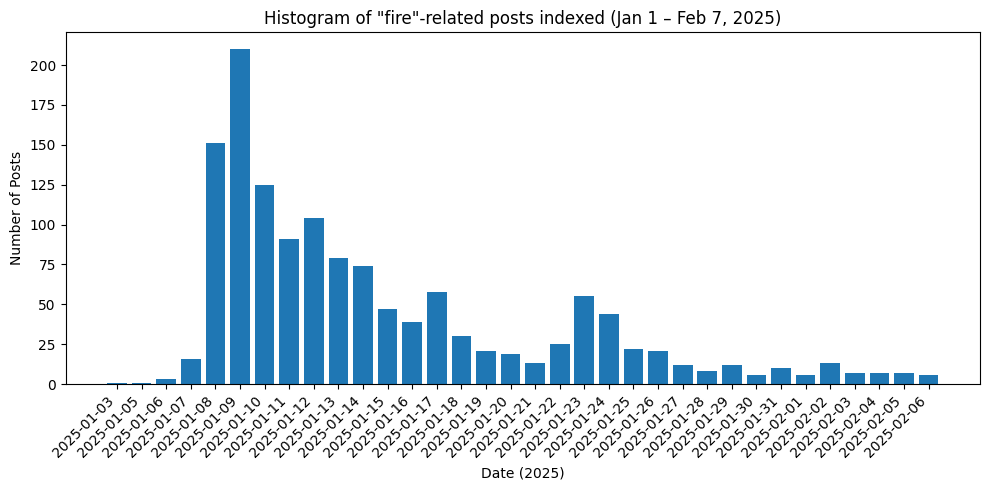

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# --- Load JSON lines ---
data = []
with open("ca_fire_20250101_20250207.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            obj = json.loads(line)
            data.append(obj)
        except json.JSONDecodeError:
            pass

# --- Extract indexed_at and convert to datetime ---
df = pd.DataFrame(data)
df["indexed_at"] = pd.to_datetime(df["indexed_at"], utc=True)

# --- Define range ---
start = pd.Timestamp("2025-01-01", tz="UTC")
end = pd.Timestamp("2025-02-07", tz="UTC")

# --- Detect records outside interval ---
outside = df[(df["indexed_at"] < start) | (df["indexed_at"] > end)]
if not outside.empty:
    print("The following records fall outside Jan 1 – Feb 7, 2025:")
    print(outside[["indexed_at", "author_handle", "uri"]])
else:
    print("All records are within the date interval.")

# --- Filter to keep only those inside range ---
df = df[(df["indexed_at"] >= start) & (df["indexed_at"] <= end)]

# --- Group by day ---
df["day"] = df["indexed_at"].dt.date
counts = df["day"].value_counts().sort_index()

# --- Plot histogram ---
plt.figure(figsize=(10,5))
plt.bar(counts.index.astype(str), counts.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Date (2025)")
plt.ylabel("Number of Posts")
plt.title("Histogram of \"fire\"-related posts indexed (Jan 1 – Feb 7, 2025)")
plt.tight_layout()
plt.show()